# [LAB-06] 12. Convex Hull - 연습문제

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import my_plot
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 셋 가져오기

In [2]:
origin = load_data("byeolbit_city")
origin.head()

📚 가상의 신도시 별빛시(Byeolbit City) 의 도시계획 데이터


,시설ID,시설명,구역,X좌표,Y좌표,일평균방문객
0,1001,상가01,상업지구,6.270,8.830,923
1,1002,상가02,상업지구,5.060,7.900,929
2,1003,상가03,상업지구,6.680,8.760,1442
3,1004,상가04,상업지구,6.850,7.830,678
4,1005,상가05,상업지구,4.240,9.110,646


## #02. 구역별 시각화

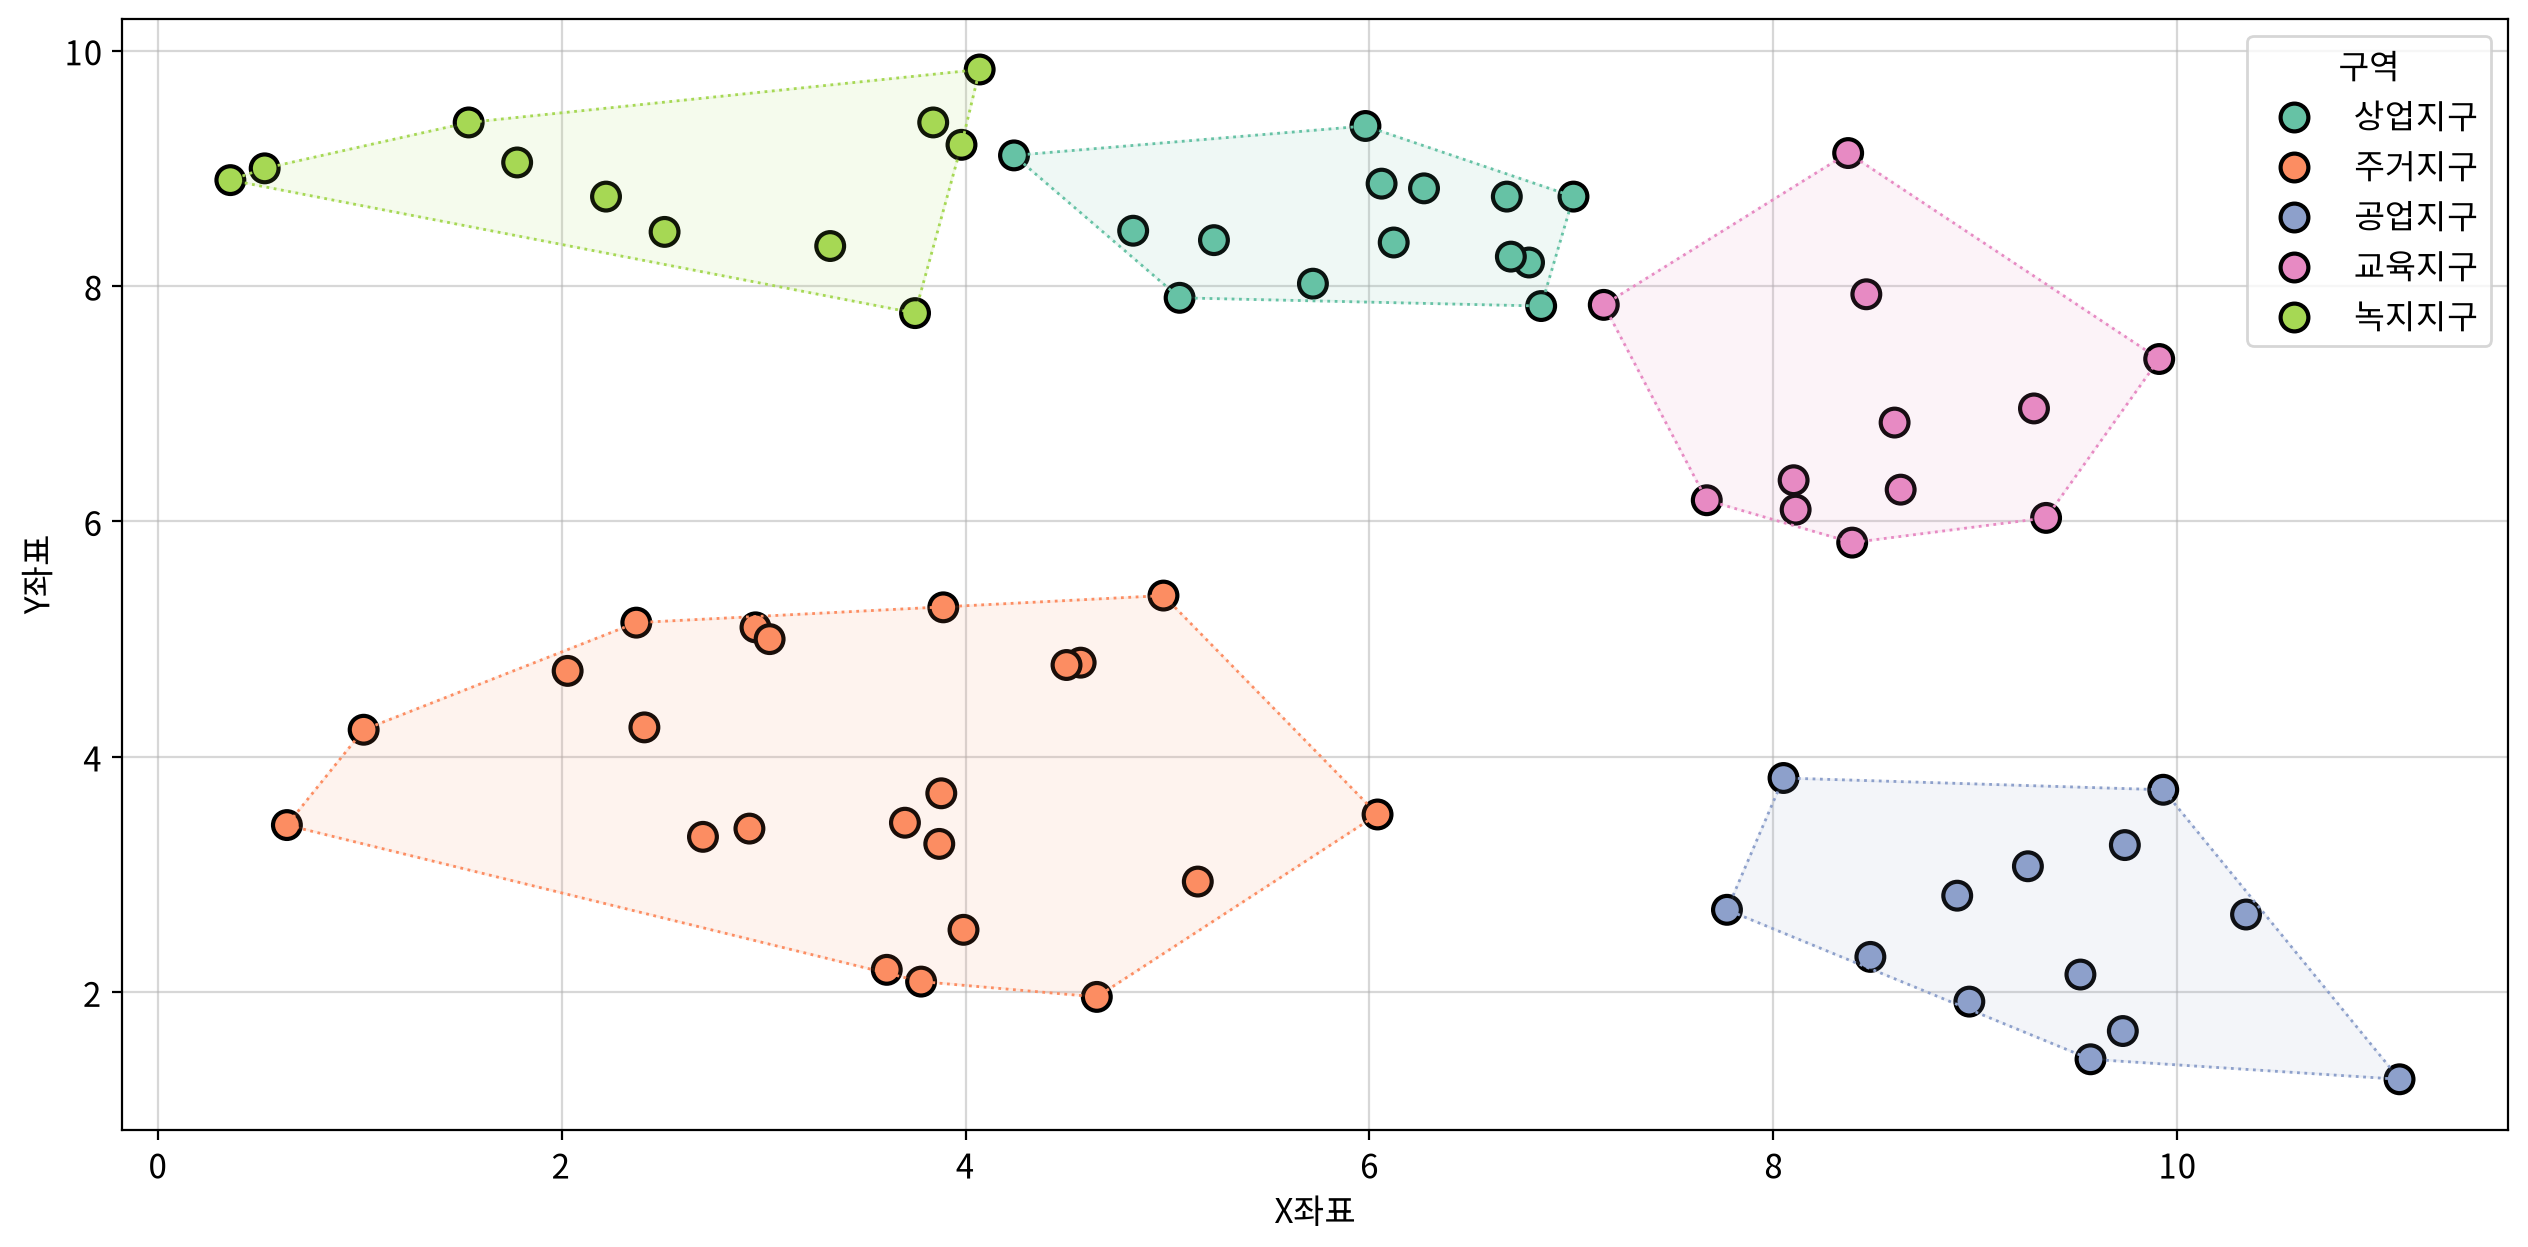

In [3]:
my_plot.scatterplot(data=origin, 
                    x='X좌표', y='Y좌표', hue='구역',
                    size=100, edgecolor="#000000", linewidth=1.5, palette='Set2')

## #03. 문제풀이

### 문제 1

별빛시의 5개 구역 중 ConvexHull로 그린 **영토(영역)의 넓이가 가장 넓은 구역** 과 **가장 좁은 구역** 을 순서대로 고르시오.

- **정답**: 가장 넓은 구역 = **주거지구**(약 12.0㎢), 가장 좁은 구역 = **상업지구**(약 3.0㎢)
- **해설**: ConvexHull의 면적은 2차원에서 `hull.volume` 으로 구할 수 있다. 데이터 생성 시 주거지구(아파트)는 표준편차 `spread`를 (1.7, 1.6)으로 크게 설정해 도시 전역에 넓게 흩어지도록 만들었기 때문에 점들을 감싸는 볼록 껍질의 면적이 가장 크다(≈12.0㎢). 반대로 상업지구(상가)는 `spread`가 (0.9, 0.7)로 가장 작아 도심에 조밀하게 밀집하므로 영역이 가장 좁다(≈3.0㎢). 산점도에서도 주거지구 점들이 가장 넓게 퍼져 있고 상업지구 점들이 가장 뭉쳐 있는 것으로 시각적으로 확인된다. 즉, ConvexHull 면적은 **데이터 포인트의 산포(분산) 정도** 를 직관적으로 보여준다.

### 문제 2

완성된 영토 지도에서, 서로 다른 구역의 ConvexHull 경계선(영토)이 **겹치는(중첩되는) 구역 쌍** 이 존재하는가? 그렇게 판단한 근거는 무엇인가?

- **정답**: 겹치는 구역 쌍은 **존재하지 않는다.** 5개 구역의 영토가 모두 **공간적으로 분리** 되어 있다.
- **해설**: 각 구역은 중심 좌표(center)를 서로 멀리 떨어뜨려 생성했다(예: 상업지구 (6.0, 8.5), 주거지구 (3.5, 4.0), 공업지구 (9.5, 2.5), 교육지구 (8.5, 7.0), 녹지지구 (2.0, 9.0)). 그 결과 각 구역의 점 군집이 지도 위 서로 다른 자리에 모여 있어 볼록 껍질끼리 교차하지 않는다. 이는 **용도지역이 뚜렷하게 구획된, 계획이 잘 된 도시** 임을 의미한다. 만약 두 구역의 영토가 겹친다면 해당 지역은 용도가 혼재(예: 주상복합)되어 있다고 해석할 수 있다. ConvexHull 시각화는 이처럼 **군집 간 분리/중첩 여부** 를 한눈에 파악하는 데 유용하다.

### 문제 3

각 구역의 ConvexHull을 구성하는 **꼭짓점(최외곽 경계 시설)의 개수** 를 비교했을 때, 꼭짓점이 **가장 많은 구역** 은 어디이며 그 개수는 몇 개인가?

- **정답**: **주거지구** 이며, 꼭짓점의 개수는 **7개** 이다.
- **해설**: ConvexHull의 꼭짓점은 `hull.vertices` 의 길이로 알 수 있다(시작점을 끝에 다시 더해 도형을 닫기 *전* 의 개수). 점들이 넓고 불규칙하게 퍼질수록 외곽 경계를 이루는 꼭짓점이 많아지는 경향이 있다. 가장 넓게 분산된 주거지구가 7개의 꼭짓점으로 가장 복잡한 다각형 경계를 이루며, 상업지구·공업지구처럼 조밀하거나 한쪽으로 모인 구역은 5개 안팎의 단순한 경계를 가진다. 이 꼭짓점에 해당하는 시설들이 곧 그 구역의 **"국경"에 위치한 시설(최외곽 시설)** 이며, ConvexHull 알고리즘은 내부의 수많은 점은 무시하고 오직 이 바깥쪽 점들만으로 영역을 정의한다.